Using device: mps
Evaluating on 304 samples from Test set.
Running Ensemble Inference...


Members: 100%|██████████| 3/3 [00:27<00:00,  9.28s/it]


Calculating Calibration Metrics...


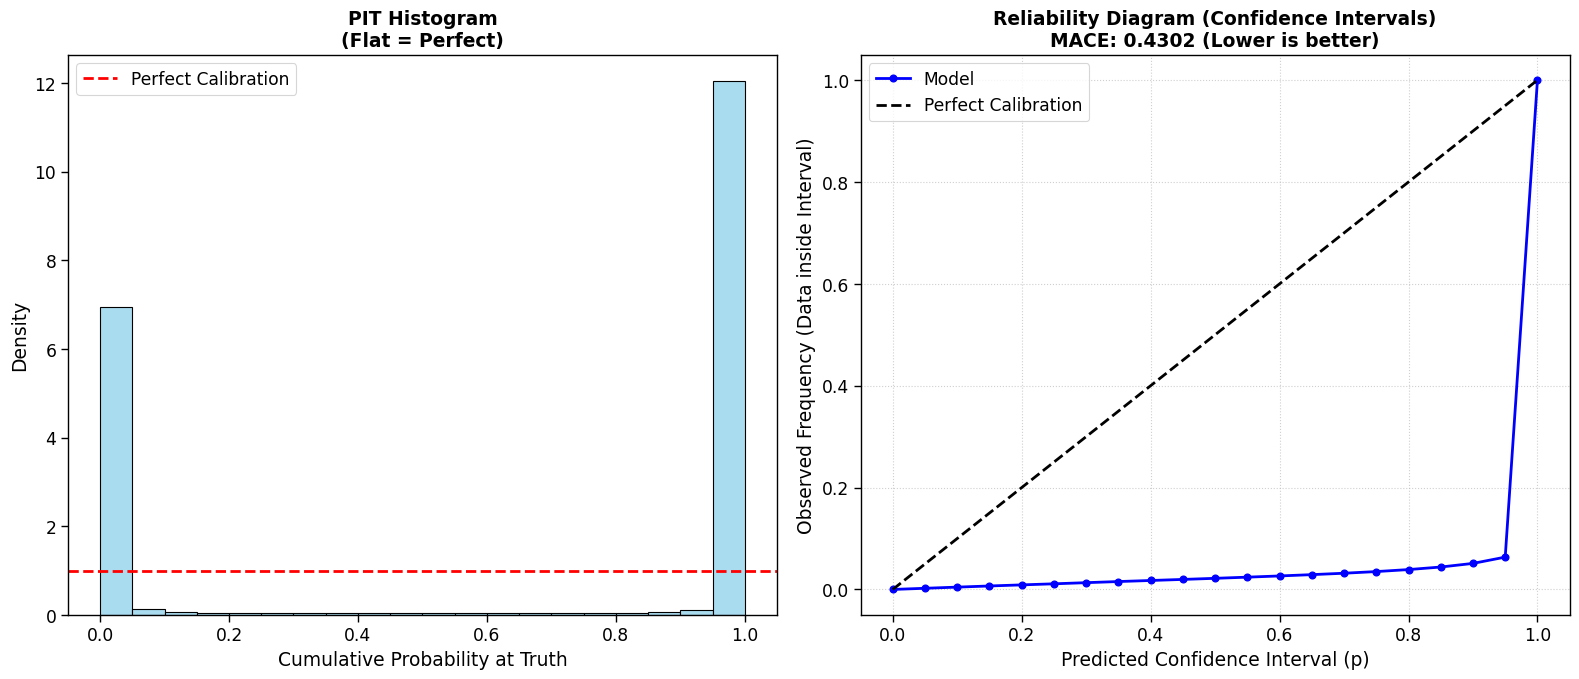

In [4]:
import glob
import json
import os
import numpy as np
import xarray as xr
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from unet import ProbUNet

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# Set a limit to speed up analysis (None = use all test samples)
NUM_SAMPLES = None
BATCH_SIZE = 20

# Lat/Lon dimensions
lat_dim = 128
num_bins = 64

# Model Architecture Config (Must match training)
base_channels = 200
gn_groups = 1
kernel_size = 3

dP_min = -700
dP_max = 1200

# Paths
base_dir = Path("/Users/ewellmeyer/Documents/research")
data_dir = base_dir / "HadGEM"
input_file = data_dir / f"GA789_PR_his_rg{lat_dim}.nc"
truth_file = data_dir / f"GA789_dPdK_rg{lat_dim}.nc"
landmask_file = data_dir / "hadgem_landmask_rg128.nc"

# Ensemble Directory
ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}"
)
ens_dir = Path("/Users/ewellmeyer/Documents/research/weights") / ens_name
norm_stats_path = ens_dir / "norm_stats.json"
bin_info_path   = ens_dir / "born_bins.json"
split_ind_path  = ens_dir / "data_splits.npz"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
def load_data():
    # Load Stats
    with open(norm_stats_path, "r") as f:
        ns = json.load(f)
    x_mean = np.array(ns["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
    x_std  = np.array(ns["x_std"],  dtype=np.float32).reshape(1, 1, 1, 1)
    y_mean = float(ns["y_mean"])
    y_std  = float(ns["y_std"])

    # Load Bin Centers
    with open(bin_info_path, "r") as f:
        bi = json.load(f)
    bin_centers = np.array(bi["bin_centers_norm"], dtype=np.float32)

    # Load Splits
    splits = np.load(split_ind_path)
    test_indices = splits["test"]

    if NUM_SAMPLES is not None:
        if NUM_SAMPLES < len(test_indices):
            test_indices = np.random.choice(test_indices, NUM_SAMPLES, replace=False)
            test_indices.sort()

    print(f"Evaluating on {len(test_indices)} samples from Test set.")

    # Load NetCDF Data
    ds_in = xr.open_dataset(input_file)
    ds_tar = xr.open_dataset(truth_file)

    # Load Landmask
    ds_lm = xr.open_dataset(landmask_file)
    landmask = ds_lm['land_mask'].values

    # Extract arrays: (N, 1, H, W)
    X_full = ds_in.to_array().values.astype(np.float32)
    y_full = ds_tar.to_array().values.astype(np.float32)
    X_full = np.transpose(X_full, (1, 0, 2, 3))
    y_full = np.transpose(y_full, (1, 0, 2, 3))

    # Select Test Data
    X_test = X_full[test_indices]
    y_test = y_full[test_indices]

    # Normalize
    X_test_norm = (X_test - x_mean) / x_std
    y_test_norm = (y_test - y_mean) / y_std

    return X_test_norm, y_test_norm, bin_centers, landmask, y_mean, y_std

# ==============================================================================
# 3. ENSEMBLE INFERENCE & CDF CALCULATION
# ==============================================================================
def get_predicted_cdfs(X_norm, bin_centers):
    """
    Returns the Cumulative Distribution Function (CDF) for every pixel
    averaged across the ensemble.
    """
    member_files = sorted(glob.glob(str(ens_dir / f"{ens_dir.name}_member*.pth")))
    if not member_files:
        raise ValueError(f"No checkpoint files found in {ens_dir}")

    N, _, H, W = X_norm.shape
    accum_probs = np.zeros((N, num_bins, H, W), dtype=np.float32)

    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)

    print("Running Ensemble Inference...")
    for m_file in tqdm(member_files, desc="Members"):
        ckpt = torch.load(m_file, map_location=device)
        state = ckpt["model"] if "model" in ckpt else ckpt
        model.load_state_dict(state, strict=False)
        model.eval()

        with torch.inference_mode():
            for i in range(0, N, BATCH_SIZE):
                batch_X = torch.as_tensor(X_norm[i:i+BATCH_SIZE], dtype=torch.float32, device=device)
                probs = model.forward_components(batch_X).float()
                accum_probs[i:i+BATCH_SIZE] += probs.cpu().numpy()

    # Average probabilities across members
    avg_probs = accum_probs / len(member_files)

    # CDF via cumulative sum over bin dimension (axis 1): (N, num_bins, H, W)
    cdf = np.cumsum(avg_probs, axis=1)
    cdf[:, -1, :, :] = 1.0  # fix float accumulation errors

    return cdf

# ==============================================================================
# 4. CALCULATE RELIABILITY (PIT HISTOGRAM & INTERVAL CALIBRATION)
# ==============================================================================
def calculate_calibration(cdf, y_true_norm, bin_centers, landmask):
    """
    Probability Integral Transform (PIT).
    For a calibrated model, the CDF value at the true observation
    should be uniformly distributed U[0,1].
    """
    print("Calculating Calibration Metrics...")

    # Filter to land only
    land_indices = np.where(landmask == 1)

    # Flatten: y_true_norm (N, 1, H, W) -> land pixels
    y_flat = y_true_norm[:, 0, :, :][:, land_indices[0], land_indices[1]].flatten()

    # cdf (N, bins, H, W) -> (N_points, num_bins)
    cdf_flat = cdf[:, :, land_indices[0], land_indices[1]]
    cdf_flat = cdf_flat.reshape(-1, num_bins)

    n_points = len(y_flat)

    # Interpolate CDF to find probability at true value (PIT)
    idx = np.searchsorted(bin_centers, y_flat)
    idx = np.clip(idx, 1, num_bins - 1)

    x0 = bin_centers[idx - 1]
    x1 = bin_centers[idx]
    y0 = cdf_flat[np.arange(n_points), idx - 1]
    y1 = cdf_flat[np.arange(n_points), idx]

    pit_values = y0 + (y_flat - x0) * (y1 - y0) / (x1 - x0)
    pit_values = np.clip(pit_values, 0.0, 1.0)

    return pit_values

# ==============================================================================
# 5. PLOTTING
# ==============================================================================
def plot_reliability(pit_values):
    sns.set_context("paper", font_scale=1.4)
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))

    # PIT Histogram
    sns.histplot(pit_values, bins=20, stat='density', ax=ax[0], color='skyblue', edgecolor='black', alpha=0.7)
    ax[0].axhline(1.0, color='red', linestyle='--', linewidth=2, label="Perfect Calibration")
    ax[0].set_title("PIT Histogram\n(Flat = Perfect)", fontweight='bold')
    ax[0].set_xlabel("Cumulative Probability at Truth")
    ax[0].set_ylabel("Density")
    ax[0].legend()

    # Reliability Diagram
    expected_probs = np.linspace(0, 1, 21)
    observed_freqs = []
    for p in expected_probs:
        lower_q = 0.5 - p / 2
        upper_q = 0.5 + p / 2
        count = np.sum((pit_values >= lower_q) & (pit_values <= upper_q))
        observed_freqs.append(count / len(pit_values))

    ax[1].plot(expected_probs, observed_freqs, 'o-', color='blue', linewidth=2, label='Model')
    ax[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')

    mace = np.mean(np.abs(np.array(observed_freqs) - expected_probs))
    ax[1].set_title(f"Reliability Diagram (Confidence Intervals)\nMACE: {mace:.4f} (Lower is better)", fontweight='bold')
    ax[1].set_xlabel("Predicted Confidence Interval (p)")
    ax[1].set_ylabel("Observed Frequency (Data inside Interval)")
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
X_test, y_test, bin_centers, landmask, y_mean, y_std = load_data()
cdf = get_predicted_cdfs(X_test, bin_centers)
pit_values = calculate_calibration(cdf, y_test, bin_centers, landmask)
plot_reliability(pit_values)